# Regresion lasso

este tipo de regresion es muy similar en concepto a la regresion ridge lineal, pero a diferencia de la ridge lo que hacemos aca 
es poner una penalizacion igual a cero, para que datos que tengan informacion que generan riuido los podamos 
minimizar a casi cero y asi poder que ellos no afecten a la predicion.

para este caso vamos a decir que la regresion ridge usa una penalizacion L2 mientras que la regresion lasso usa 
una penalizacion L1 que es mucho mas castigadora a los datos que solo estan generand ruido , ya que baja sus valores a cero

## Lasso usando la libreria de scikit

In [39]:
# traer con pandas las informacion para analizar y transformar
import pandas as pd
import numpy as np

dataSetBoston = pd.read_csv('../Data_sets/BostonHousing.csv')

CRIM = 0; ZN = 1; ROOMS = 5; LSTAT = 12

columns = np.array(dataSetBoston.columns[[CRIM,ZN,ROOMS,LSTAT]])

labels = np.array(['Crime por capita', 'zonas de residencia', 'Numero de cuartos', 'Status bajo de la problacion'])

# vamos a limpir la data de rooms que tiene valores que no son validos
dataSetBoston['rm'] = dataSetBoston['rm'].map(lambda x: x if str(x) != 'nan' else 0)


slope: [-0.41112746], Intercepto: 24.018425082751754
slope: [0.14158737], Intercepto: 20.923858967771817
slope: [4.9621124], Intercepto: -8.342663211385073
slope: [-0.94415475], Intercepto: 34.47925604595717


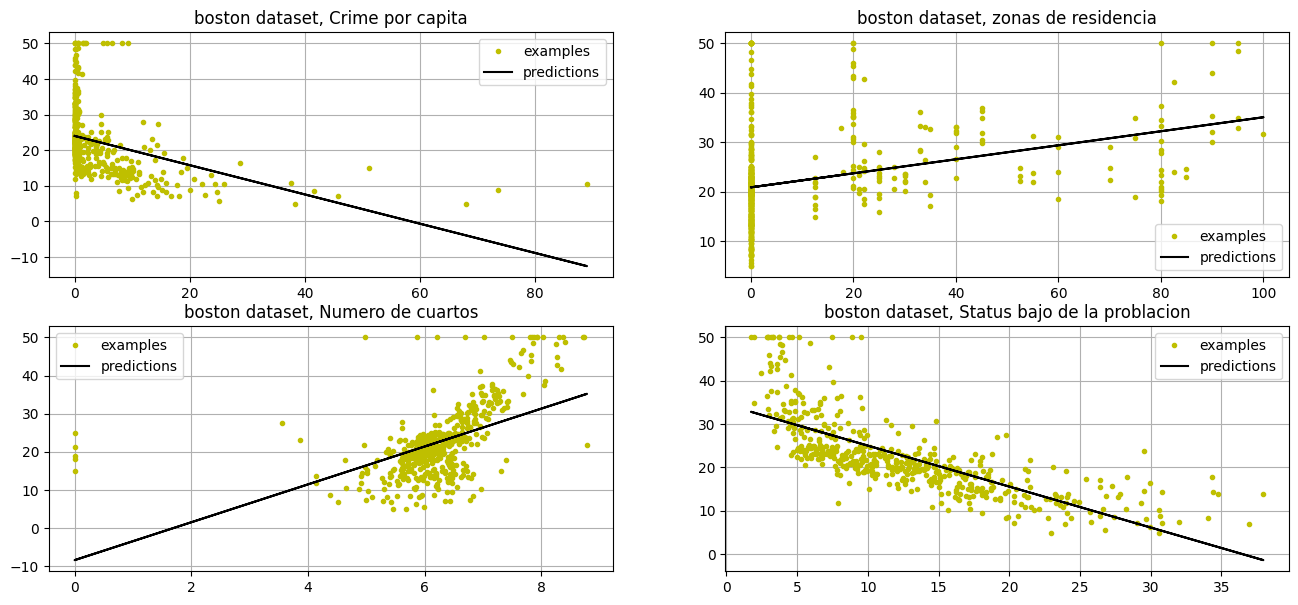

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import Lasso


fig, axs = plt.subplots(2,2,figsize=(16,7))

def plot(data2D,target1D, prediction1D, i, labels):
    axs[int(i/2),i%2].plot(data2D,target1D,'y.', markersize=6 ,label='examples')

    axs[int(i/2),i%2].plot(data2D,prediction1D, 'k-', label='predictions')
    axs[int(i/2),i%2].legend()
    axs[int(i/2),i%2].set_title('boston dataset, '+ labels[i])
    axs[int(i/2),i%2].grid()
    return

y = dataSetBoston['medv']

for i, attribute in zip(range(4), columns):
    X = np.array(dataSetBoston[attribute])
    X = X[:,np.newaxis]

    lasso = Lasso(alpha=0.3)
    lasso.fit(X,y)
    print("slope: " + str(lasso.coef_) + ", Intercepto: "+ str(lasso.intercept_))
    y_pred = lasso.predict(X)
    plot(X,y,y_pred, i, labels)
